In [32]:
import slmcontrol
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import affine_transform
from cameras.ImagingSourceNew import ImagingSourceCamera
from cameras.Ximea import XimeaCamera
from scipy.linalg import polar
from phase_screens import fourier_phase_screen
from augmented_gs import augmented_gs, fidelity
import jax
import jax.numpy as jnp
from utils import set_phase_reference, crop_center
from scipy.linalg import norm, inv

In [2]:
def remove_background(img, bg):
    return np.where(img > bg, img - bg, 0)

In [3]:
slm = slmcontrol.SLMDisplay(host="localhost")
_xs = np.arange(slm.width // 2) - slm.width//4
_ys = np.arange(slm.height) - slm.height//2
xs, ys = np.meshgrid(_xs, _ys)

In [4]:
mode = slmcontrol.lg(xs, ys, p=0, l=1, w=50)
holo = slmcontrol.generate_hologram(np.concatenate([np.exp(-1j * np.angle(mode)), mode], axis = 1), 192, -3, 19)
slm.updateArray(holo)

In [5]:
camera_direct = ImagingSourceCamera()

In [6]:
camera_reciprocal = XimeaCamera()

In [7]:
with h5py.File("calibration/calibration.h5") as f:
    A_direct = f["A_direct"][:]
    t_direct = f["t_direct"][:]
    A_reciprocal = f["A_reciprocal"][:]
    t_reciprocal = f["t_reciprocal"][:]

u_direct, p_direct = polar(A_direct)
u_reciprocal, p_reciprocal = polar(A_reciprocal)

In [8]:
holo = np.zeros((slm.height, slm.width), dtype=np.uint8)
slm.updateArray(holo)
bg_direct = camera_direct.capture().mean()
bg_reciprocal = camera_reciprocal.capture().mean()

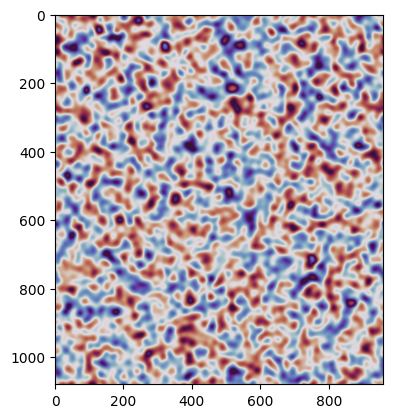

In [9]:
amplitude = 2**26
sigma = 0.5 / 2 / np.pi

phase_mask = fourier_phase_screen(slm.height, slm.width // 2, amplitude=amplitude, sigma=sigma)
phase_transformation = np.exp(1j * phase_mask)
rotated_phase_transformation = affine_transform(phase_transformation, u_direct)

plt.imshow(phase_mask, cmap="twilight")

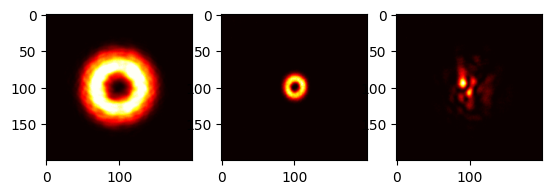

In [34]:
mode = slmcontrol.lg(xs, ys, p=0, l=2, w=30)

rotated_phase_transformation = np.flip(phase_transformation) # affine_transform(phase_transformation, np.flip(inv(u_direct), axis=1))

two_pi_modulation = 192

holo_mode = slmcontrol.generate_hologram(mode, two_pi_modulation, -3, 19)
holo_fourier = slmcontrol.generate_hologram(np.ones_like(mode), two_pi_modulation, -3, 19)
holo_phase_fourier = slmcontrol.generate_hologram(rotated_phase_transformation, two_pi_modulation, -3, 19)

holo1 = np.concatenate([holo_fourier, holo_mode], axis=1)
holo2 = np.concatenate([holo_phase_fourier, holo_mode], axis=1)

slm.updateArray(holo2)

camera_direct.set_exposure(100)
camera_reciprocal.set_exposure(100)


slm.updateArray(holo1)
image_direct = np.flip(camera_direct.capture(), axis=0)
image_fourier = np.flip(camera_reciprocal.capture(), axis=0)
slm.updateArray(holo2)
image_phase_fourier = np.flip(camera_reciprocal.capture(), axis=0)

bg_direct = 2
bg_reciprocal = 5

image_direct = remove_background(image_direct, bg_direct)
image_fourier = remove_background(image_fourier, bg_reciprocal)
image_phase_fourier = remove_background(image_phase_fourier, bg_reciprocal)

fig, axs = plt.subplots(1, 3, )


corrected_image_direct = affine_transform(image_direct, A_direct, t_direct, mode.shape)
corrected_image_fourier = affine_transform(image_fourier, A_reciprocal, t_reciprocal, mode.shape)
corrected_image_phase_fourier = affine_transform(image_phase_fourier, A_reciprocal, t_reciprocal, mode.shape)

axs[0].imshow(crop_center(corrected_image_direct, 200), cmap="hot")
axs[1].imshow(crop_center(corrected_image_fourier, 200), cmap="hot")
axs[2].imshow(crop_center(corrected_image_phase_fourier, 200), cmap="hot")

plt.show()

In [35]:
initial_phases = jax.random.uniform(jax.random.key(0), (1, *mode.shape))

direct_amplitude = np.sqrt(corrected_image_direct).astype(np.float32)
fourier_amplitude = np.fft.fftshift(np.sqrt(corrected_image_fourier).astype(np.float32))
phase_fourier_amplitude = np.fft.fftshift(np.sqrt(corrected_image_phase_fourier).astype(np.float32))

direct_amplitude /= norm(direct_amplitude)
fourier_amplitude *= np.sqrt(np.prod(mode.shape)) / norm(fourier_amplitude)
phase_fourier_amplitude *= np.sqrt(np.prod(mode.shape)) / norm(phase_fourier_amplitude)


u_fourier = jnp.fft.fft2(mode)
u_phase_fourier = jnp.fft.fft2(phase_transformation * mode)

predicted_phase = augmented_gs(
    direct_amplitude, fourier_amplitude, phase_fourier_amplitude, phase_transformation, initial_phases, 200
)

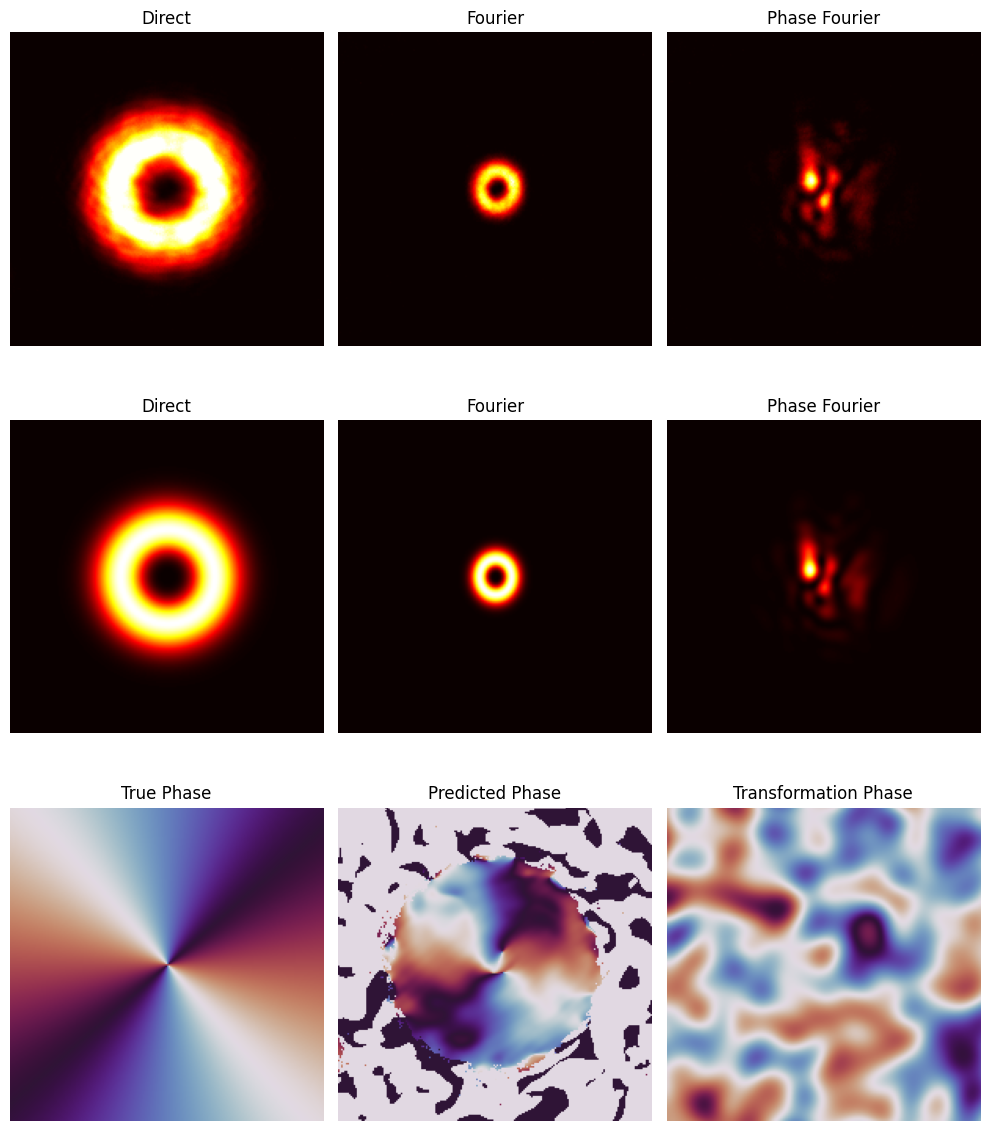

In [36]:
size = 200

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(10, 12))
axs[0, 0].imshow(crop_center(jnp.abs(direct_amplitude) ** 2, size), cmap="hot")
axs[0, 0].set_title("Direct")

axs[0, 1].imshow(crop_center(jnp.fft.fftshift(jnp.abs(fourier_amplitude) ** 2), size), cmap="hot")
axs[0, 1].set_title("Fourier")

axs[0, 2].imshow(crop_center(jnp.fft.fftshift(jnp.abs(phase_fourier_amplitude) ** 2), size), cmap="hot")
axs[0, 2].set_title("Phase Fourier")

axs[1, 0].imshow(crop_center(jnp.abs(mode) ** 2, size), cmap="hot")
axs[1, 0].set_title("Direct")

axs[1, 1].imshow(crop_center(jnp.fft.fftshift(jnp.abs(u_fourier) ** 2), size), cmap="hot")
axs[1, 1].set_title("Fourier")

axs[1, 2].imshow(crop_center(jnp.fft.fftshift(jnp.abs(u_phase_fourier) ** 2), size), cmap="hot")
axs[1, 2].set_title("Phase Fourier")

axs[2, 0].imshow(
    crop_center(set_phase_reference(jnp.angle(mode), posX=0.45, posY=0.45), size),
    cmap="twilight",
    vmin=-jnp.pi,
    vmax=jnp.pi,
)
axs[2, 0].set_title("True Phase")

axs[2, 1].imshow(
    crop_center(set_phase_reference(predicted_phase, posX=0.45, posY=0.45), size),
    cmap="twilight",
    vmin=-jnp.pi,
    vmax=jnp.pi,
)
axs[2, 1].set_title("Predicted Phase")

axs[2, 2].imshow(crop_center(phase_mask, size), cmap="twilight", vmin=-jnp.pi, vmax=jnp.pi)
axs[2, 2].set_title("Transformation Phase")

for m in range(axs.shape[0]):
    for n in range(axs.shape[1]):
        axs[m, n].set_axis_off()

plt.tight_layout()
plt.show()

In [37]:
fidelity(mode, direct_amplitude * jnp.exp(1j * predicted_phase))

Array(0.8885065, dtype=float32)

In [20]:
camera_reciprocal.close()